# Error analysis: where do Haukeli_G1 and Lio_G1 lose AUC?

Twelve of the fourteen units score 0.97-0.997 on the 2022 validation;
Haukeli_G1 and Lio_G1 sit around 0.92-0.94 and cost roughly 0.01 of the
micro AUC between them. Before trying another model, find out *when* they
fail.

This notebook trains the exact pipeline from `per_generator_xgboost.ipynb`
(train 2015-2021, validate 2022, early stopping on the train tail) and then
breaks the two hard units' errors down by month, hour of day, price level,
reservoir fill and week. Runtime is about 5 minutes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import yaml
from sklearn.metrics import roc_auc_score

HOURS = 168
DATA = 'data/kernel'
EXT = 'data/extended'

In [2]:
price = pd.read_csv(f'{DATA}/Historical_day_ahead_price_2015_2025.csv')
inflow = pd.read_csv(f'{DATA}/Historical_inflow_1958_2025.csv')
volume = pd.read_csv(f'{DATA}/Historical_volume_2015_2024.csv')
water = pd.read_csv(f'{DATA}/Synthetic_water_value_2015_2024.csv')
target = pd.read_csv(f'{DATA}/Unit_commitment_decisions.csv')
min_flow = pd.read_csv(f'{EXT}/Constraint_min_flow.csv')
min_volume = pd.read_csv(f'{EXT}/Constraint_min_volume.csv')
topology = yaml.safe_load(open(f'{EXT}/Tokke_Vinje_topology.yaml'))

In [3]:
def indexed(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], utc=True, format='mixed')
    return df.sort_values('date').set_index('date')


price_h = indexed(price)['Day-ahead price (EUR/MWh)'].resample('1h').mean()
inf_wide = indexed(inflow)
vol_wide = indexed(volume)
wv_wide = indexed(water)
mf_wide = indexed(min_flow)
mv_wide = indexed(min_volume)

RESERVOIRS = list(vol_wide.columns)
CAPACITY = {r: float(topology['model']['reservoir'][r]['max_vol']) for r in RESERVOIRS}

In [4]:
connections = topology['connections']


def supplying_reservoirs(name, kind):
    if kind == 'reservoir':
        return {name}
    out = set()
    for e in connections:
        if e['to'] == name and e['to_type'] == kind and e['from_type'] in {'reservoir', 'tunnel'}:
            out |= supplying_reservoirs(e['from'], e['from_type'])
    return out


GENERATORS = sorted(
    {c.removeprefix('result_committed_').rsplit('_t', 1)[0]
     for c in target.columns if c.startswith('result_committed')}
)

FEEDERS = {}
for gen in GENERATORS:
    plant = next(e['to'] for e in connections
                 if e['from'] == gen and e['from_type'] == 'generator' and e['to_type'] == 'plant')
    FEEDERS[gen] = sorted(supplying_reservoirs(plant, 'plant'))

In [5]:
def lookup(frame, timestamps, columns=None):
    f = frame if columns is None else frame[columns]
    return f.reindex(pd.DatetimeIndex(timestamps)).to_numpy(dtype=np.float32)


def feature_matrix(cases):
    starts = pd.DatetimeIndex(cases['starttime'])
    n = len(starts)
    ts = pd.DatetimeIndex(np.repeat(starts.to_numpy(), HOURS)) + pd.to_timedelta(
        np.tile(np.arange(HOURS), n), unit='h'
    )
    price = lookup(price_h, ts).reshape(n, HOURS)
    initial = lookup(vol_wide, starts, RESERVOIRS)
    terminal = lookup(wv_wide, starts + pd.Timedelta(hours=HOURS), RESERVOIRS)
    inflow = lookup(inf_wide, ts).reshape(n, HOURS, -1)
    minflow = lookup(mf_wide, ts).reshape(n, HOURS, -1)
    minvol = lookup(mv_wide, ts).reshape(n, HOURS, -1)

    F = {}

    def add(name, v):
        v = np.asarray(v, dtype=np.float32)
        if v.shape == (n,):
            v = np.repeat(v, HOURS)
        elif v.shape == (n, HOURS):
            v = v.reshape(-1)
        F[name] = v

    h = np.tile(np.arange(HOURS, dtype=np.float32), n)
    add('horizon_hour', h)
    add('hours_remaining', HOURS - 1 - h)
    add('hour_of_day', ts.hour.to_numpy())
    add('day_of_week', ts.dayofweek.to_numpy())
    add('month', ts.month.to_numpy())
    add('doy_sin', np.sin(2 * np.pi * ts.dayofyear.to_numpy() / 365.25))
    add('doy_cos', np.cos(2 * np.pi * ts.dayofyear.to_numpy() / 365.25))

    add('price', price)
    for stat, v in (('mean', price.mean(1)), ('std', price.std(1)),
                    ('min', price.min(1)), ('max', price.max(1))):
        add(f'price_week_{stat}', v)
    add('price_minus_week_mean', price - price.mean(1, keepdims=True))
    add('price_week_rank', pd.DataFrame(price).rank(axis=1, pct=True).to_numpy())
    daily = price.reshape(n, 7, 24)
    for stat, v in (('mean', daily.mean(2)), ('min', daily.min(2)), ('max', daily.max(2))):
        add(f'price_day_{stat}', np.repeat(v, 24, axis=1))
    add('price_prefix_mean', price.cumsum(1) / np.arange(1, HOURS + 1))
    add('price_suffix_mean', price[:, ::-1].cumsum(1)[:, ::-1] / np.arange(HOURS, 0, -1))
    for off in (-24, -6, -1, 1, 6, 24):
        add(f'price_offset_{off:+d}', price[:, np.clip(np.arange(HOURS) + off, 0, HOURS - 1)])

    for j, res in enumerate(RESERVOIRS):
        add(f'init_vol__{res}', initial[:, j])
        add(f'init_frac__{res}', initial[:, j] / CAPACITY[res])
        add(f'term_val__{res}', terminal[:, j])
        add(f'price_minus_val__{res}', price - terminal[:, j, None])

    for j, name in enumerate(inf_wide.columns):
        flow = inflow[:, :, j]
        cum = flow.cumsum(1) * (3600 / 1e6)
        add(f'inflow__{name}', flow)
        add(f'inflow_week_mean__{name}', flow.mean(1))
        add(f'inflow_cum_Mm3__{name}', cum)
        add(f'inflow_rem_Mm3__{name}', cum[:, -1:] - cum)

    for j, name in enumerate(mf_wide.columns):
        add(f'minflow__{name}', minflow[:, :, j])
        add(f'minflow_week_max__{name}', minflow[:, :, j].max(1))
    for j, name in enumerate(mv_wide.columns):
        add(f'minvol__{name}', minvol[:, :, j])
        add(f'minvol_week_max__{name}', minvol[:, :, j].max(1))
        add(f'init_margin_to_minvol__{name}', initial[:, RESERVOIRS.index(name), None] - minvol[:, :, j])

    return pd.DataFrame(F, dtype=np.float32)

In [6]:
def generator_features(base, gen):
    X = base.copy()
    feeders = FEEDERS[gen]
    capacity = sum(CAPACITY[r] for r in feeders)
    total_init = sum(base[f'init_vol__{r}'] for r in feeders)
    value = sum(base[f'term_val__{r}'] * CAPACITY[r] for r in feeders) / capacity
    cum = sum(base[f'inflow_cum_Mm3__{r}'] for r in feeders)
    rem = sum(base[f'inflow_rem_Mm3__{r}'] for r in feeders)

    X['local_init_frac'] = total_init / capacity
    X['local_term_val'] = value
    X['local_price_minus_val'] = base['price'] - value
    X['local_inflow'] = sum(base[f'inflow__{r}'] for r in feeders)
    X['local_cum_frac'] = cum / capacity
    X['local_rem_frac'] = rem / capacity
    X['local_available_frac'] = (total_init + cum + rem) / capacity
    return X


def labels_for(cases, gen):
    cols = [f'result_committed_{gen}_t{t}' for t in range(HOURS)]
    return cases[cols].to_numpy(dtype=np.uint8).reshape(-1)

In [7]:
target['starttime'] = pd.to_datetime(target['starttime'], utc=True, format='mixed')
split = pd.Timestamp('2022-01-01', tz='UTC')
train_cases = target[target['starttime'] < split].reset_index(drop=True)
stop_cases = train_cases[
    train_cases['starttime'] >= split - pd.Timedelta(days=90)
].reset_index(drop=True)
val_cases = target[target['starttime'] >= split].reset_index(drop=True)

Xtr_base = feature_matrix(train_cases)
Xst_base = feature_matrix(stop_cases)
Xva_base = feature_matrix(val_cases)

preds = {}
for gen in GENERATORS:
    Xtr = generator_features(Xtr_base, gen)
    Xst = generator_features(Xst_base, gen)
    Xva = generator_features(Xva_base, gen)
    ytr = labels_for(train_cases, gen)
    yst = labels_for(stop_cases, gen)
    yva = labels_for(val_cases, gen)

    if np.unique(ytr).size == 1:
        preds[gen] = np.full(len(yva), float(ytr[0]), dtype=np.float32)
        print(f'{gen:16s} AUC   -  (constant in train)')
        continue

    clf = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, tree_method='hist',
        eval_metric='auc', early_stopping_rounds=25, random_state=0,
    )
    clf.fit(Xtr, ytr, eval_set=[(Xst, yst)], verbose=False)
    preds[gen] = clf.predict_proba(Xva)[:, 1].astype(np.float32)
    print(f'{gen:16s} AUC {roc_auc_score(yva, preds[gen]):.4f}')

Byrte_G1         AUC 0.9951
Haukeli_G1       AUC 0.9352
Hogga_G1         AUC 0.9722
Kjela_G1         AUC 0.9789
Lio_G1           AUC 0.9225
Songa_G1         AUC 0.9966
Tokke_G1         AUC 0.9928
Tokke_G2         AUC 0.9839
Tokke_G3         AUC 0.9886
Tokke_G4         AUC 0.9810
Vesle Kjela_G1   AUC 0.9815
Vinje_G1         AUC 0.9835
Vinje_G2         AUC 0.9765
Vinje_G3         AUC 0.9701


## What counts as an error?

AUC only cares about the *ranking* of scores, but to see where the model
struggles we use a fixed threshold of 0.5:

- **false positive (FP)**: predicted on (score >= 0.5), actually off
- **false negative (FN)**: predicted off, actually on

If FPs and FNs cluster in specific months, hours or price regimes, there is
signal left to extract - a missing feature or a per-unit fix. If they spread
evenly across everything, the remaining errors may be noise in the labels
themselves (the optimizer's own tie-breaking), and no model will fix that.

In [8]:
HARD = ['Haukeli_G1', 'Lio_G1']


def error_table(gen):
    starts = pd.DatetimeIndex(val_cases['starttime'])
    n = len(starts)
    ts = pd.DatetimeIndex(np.repeat(starts.to_numpy(), HOURS)) + pd.to_timedelta(
        np.tile(np.arange(HOURS), n), unit='h'
    )
    init = lookup(vol_wide, starts, RESERVOIRS)
    fidx = [RESERVOIRS.index(r) for r in FEEDERS[gen]]
    cap = sum(CAPACITY[r] for r in FEEDERS[gen])
    fill = np.repeat(init[:, fidx].sum(1) / cap, HOURS)

    t = pd.DataFrame({
        'label': labels_for(val_cases, gen).astype(bool),
        'score': preds[gen],
        'month': np.repeat(starts.month.to_numpy(), HOURS),
        'hour': ts.hour.to_numpy(),
        'price': lookup(price_h, ts),
        'fill': fill,
        'week': np.repeat(np.arange(n), HOURS),
    })
    t['fp'] = ~t['label'] & (t['score'] >= 0.5)
    t['fn'] = t['label'] & (t['score'] < 0.5)
    return t


tables = {gen: error_table(gen) for gen in HARD}
for gen, t in tables.items():
    print(f'{gen}: {t.label.sum()} on-hours, {(~t.label).sum()} off-hours, '
          f'{t.fp.sum()} FPs, {t.fn.sum()} FNs')

Haukeli_G1: 8674 on-hours, 52646 off-hours, 3649 FPs, 2641 FNs
Lio_G1: 33721 on-hours, 27599 off-hours, 3944 FPs, 7728 FNs


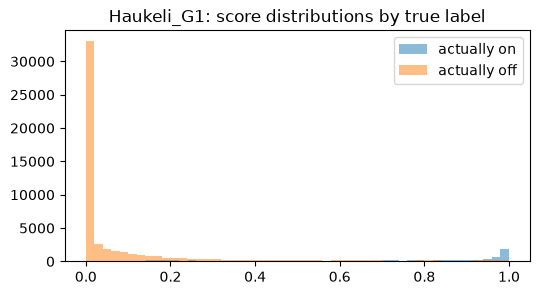

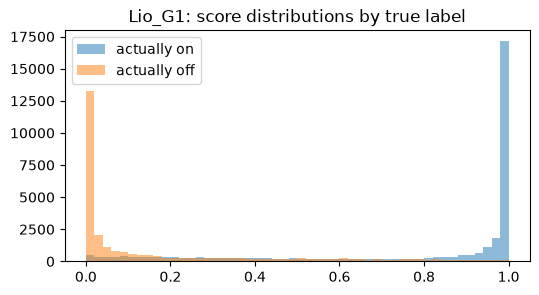

In [9]:
for gen, t in tables.items():
    plt.figure(figsize=(6, 3))
    plt.hist(t.loc[t['label'], 'score'], bins=50, alpha=0.5, label='actually on')
    plt.hist(t.loc[~t['label'], 'score'], bins=50, alpha=0.5, label='actually off')
    plt.title(f'{gen}: score distributions by true label')
    plt.legend()
    plt.show()

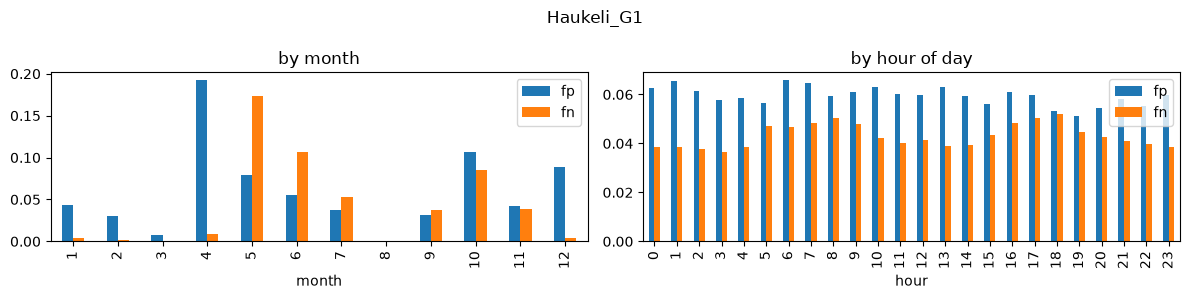

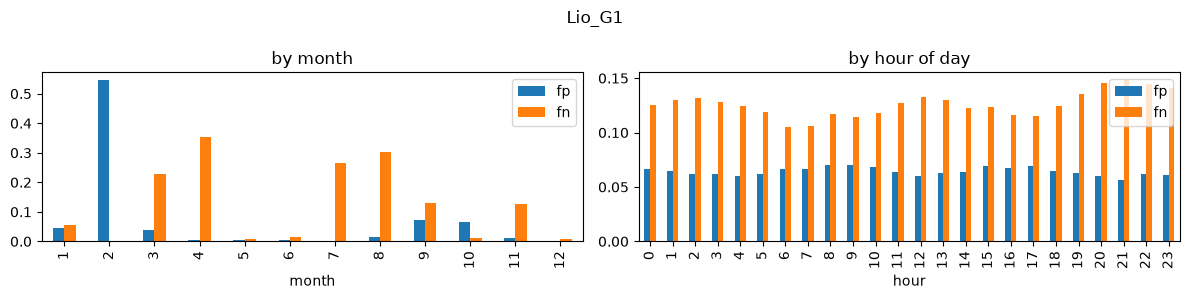

In [10]:
for gen, t in tables.items():
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    t.groupby('month')[['fp', 'fn']].mean().plot.bar(ax=ax[0], title='by month')
    t.groupby('hour')[['fp', 'fn']].mean().plot.bar(ax=ax[1], title='by hour of day')
    fig.suptitle(gen)
    plt.tight_layout()
    plt.show()

In [11]:
for gen, t in tables.items():
    t['price_bin'] = pd.cut(t['price'], [-np.inf, 20, 40, 60, 100, np.inf])
    t['fill_bin'] = pd.cut(t['fill'], [0, 0.2, 0.4, 0.6, 0.8, 1.01])
    print(gen)
    print(t.groupby('price_bin', observed=True)[['label', 'fp', 'fn']].mean().round(3))
    print(t.groupby('fill_bin', observed=True)[['label', 'fp', 'fn']].mean().round(3))
    print()

Haukeli_G1
               label     fp     fn
price_bin                         
(-inf, 20.0]   0.006  0.027  0.003
(20.0, 40.0]   0.060  0.056  0.031
(40.0, 60.0]   0.216  0.179  0.105
(60.0, 100.0]  0.139  0.123  0.027
(100.0, inf]   0.145  0.054  0.044
            label    fp     fn
fill_bin                      
(0.4, 0.6]  0.141  0.06  0.043

Lio_G1
               label     fp     fn
price_bin                         
(-inf, 20.0]   0.093  0.038  0.049
(20.0, 40.0]   0.466  0.062  0.176
(40.0, 60.0]   0.494  0.015  0.048
(60.0, 100.0]  0.410  0.089  0.041
(100.0, inf]   0.572  0.065  0.133
             label     fp     fn
fill_bin                        
(0.0, 0.2]   0.814  0.022  0.342
(0.2, 0.4]   0.324  0.331  0.022
(0.4, 0.6]   0.336  0.034  0.039
(0.6, 0.8]   0.607  0.045  0.017
(0.8, 1.01]  0.572  0.015  0.159



In [12]:
for gen, t in tables.items():
    t['err'] = t['fp'] | t['fn']
    w = t.groupby('week').agg(errors=('err', 'sum'), on_rate=('label', 'mean'))
    top = w.sort_values('errors', ascending=False).head(10)
    print(gen, '- worst 10 weeks hold', int(top['errors'].sum()),
          'of', int(t['err'].sum()), 'errors')
    print(top.T.round(3))
    print()

Haukeli_G1 - worst 10 weeks hold 1377 of 6290 errors
week       94     359    362      149     124      109      119     167  \
errors   168.0  165.0  139.0  136.000  136.00  129.000  128.000  127.00   
on_rate    0.0    0.0    0.0    0.815    0.19    0.232    0.238    0.78   

week         110      116  
errors   127.000  122.000  
on_rate    0.244    0.274  

Lio_G1 - worst 10 weeks hold 1662 of 11672 errors
week        38     95     98     97       37       48       47     96     35  \
errors   168.0  167.0  167.0  167.0  166.000  166.000  166.000  166.0  165.0   
on_rate    0.0    1.0    1.0    1.0    0.012    0.012    0.012    1.0    0.0   

week        40  
errors   164.0  
on_rate    0.0  



## What to look for in the outputs

- **Score histograms**: how much do the on and off distributions overlap? A
  long tail of confident wrong answers is a different problem from a mass of
  scores hovering near 0.5.
- **Seasonal clusters** (by month): errors concentrated in spring snowmelt or
  the autumn fill season point to a missing seasonal feature - or to
  maintenance outages, which we have no data for.
- **Hour-of-day clusters**: errors at ramp hours (morning/evening) suggest the
  price context is not sharp enough for these units.
- **Price and fill bins**: FPs at high price with full reservoirs mean the
  model overcommits; FNs at low price with empty reservoirs mean it
  undercommits. Flat error rates across all bins mean the features already
  carry what matters and the residue is noise.
- **Week concentration**: if the worst 10 weeks hold most of the errors, open
  those weeks - a handful of odd cases can dominate a unit's AUC. If errors
  are spread over many weeks, the problem is diffuse.

For contrast, run the same breakdown on a unit that scores 0.99 (e.g.
Songa_G1) by adding it to `HARD`: that shows what a healthy error profile
looks like.